# <span style="color:blue">AI Design Pattern Classification: Embedding Model Comparison</span>

This notebook conducts a comprehensive comparison of various state-of-the-art embedding models for classifying AI Design Patterns.

## <span style="color:green">1. Setup and Imports</span>
Installing and importing necessary libraries.

In [3]:
%pip install voyageai google-generativeai xgboost sentence-transformers scikit-learn pandas numpy matplotlib seaborn tqdm torch transformers einops hf_transfer tabulate tensorflow scikeras tf_keras

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline

# Models
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Embeddings
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import voyageai
import google.generativeai as genai

# Settings
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

# Enable HF Transfer for speed
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

print("Libraries installed and imported.")

Note: you may need to restart the kernel to use updated packages.
Libraries installed and imported.
Note: you may need to restart the kernel to use updated packages.
Libraries installed and imported.


In [13]:
%pip install python-dotenv
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv(dotenv_path='../.env')

print("Environment variables loaded.")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.
Environment variables loaded.


## <span style="color:green">2. Dataset Loading</span>
Loading the dataset from the generated code directory.

In [4]:
DATASET_PATH = "/root/AI-Pattern-Mining-Project/outputs/prompt & rag/20251028_085918 - Run/generated_code-v2"

def load_dataset(root_path):
    data = []
    labels = []
    
    if not os.path.exists(root_path):
        print(f"Error: Path {root_path} does not exist.")
        return pd.DataFrame()

    print(f"Scanning {root_path}...")
    for label in tqdm(os.listdir(root_path), desc="Loading Classes"):
        label_path = os.path.join(root_path, label)
        if os.path.isdir(label_path):
            for file_name in os.listdir(label_path):
                file_path = os.path.join(label_path, file_name)
                if os.path.isfile(file_path):
                    try:
                        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                            content = f.read()
                            if content.strip():
                                data.append(content)
                                labels.append(label)
                    except Exception as e:
                        pass
    
    df = pd.DataFrame({'code': data, 'label': labels})
    return df

df = load_dataset(DATASET_PATH)
print(f"Dataset loaded. Shape: {df.shape}")

# Preprocessing
import re
def preprocess_code(code):
    # Remove comments
    code = re.sub(r'//.*', '', code)
    code = re.sub(r'#.*', '', code)
    code = re.sub(r'/\*[\s\S]*?\*/', '', code)
    # Collapse whitespace
    code = re.sub(r'\s+', ' ', code).strip()
    return code

df['cleaned_code'] = df['code'].apply(preprocess_code)
print("Preprocessing complete.")

Scanning /root/AI-Pattern-Mining-Project/outputs/prompt & rag/20251028_085918 - Run/generated_code-v2...


Loading Classes: 100%|██████████| 18/18 [00:00<00:00, 133.81it/s]

Dataset loaded. Shape: (1430, 2)


Preprocessing complete.


## <span style="color:green">3. Embedding Generation</span>
Generating embeddings using various models and saving them to disk.

In [ ]:
EMBEDDING_DIR = "/root/AI-Pattern-Mining-Project/experiments-llm/embeddings"
os.makedirs(EMBEDDING_DIR, exist_ok=True)

# Helper for HF Models
def get_hf_embeddings(model_name, texts, batch_size=16, trust_remote_code=False, prefix=""):
    print(f"Generating embeddings for {model_name}...")
    try:
        # Check if it's a SentenceTransformer compatible model first (easier)
        try:
            model = SentenceTransformer(model_name, trust_remote_code=trust_remote_code)
            if prefix:
                texts = [prefix + t for t in texts]
            embeddings = model.encode(texts, show_progress_bar=True, batch_size=batch_size)
            return embeddings
        except Exception as e:
            # Fallback to raw Transformers
            print(f"SentenceTransformer failed for {model_name}: {e}")
            print(f"Trying raw Transformers for {model_name}...")
            tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=trust_remote_code)
            model = AutoModel.from_pretrained(model_name, trust_remote_code=trust_remote_code)
            
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            model.to(device)
            model.eval()
            
            all_embeddings = []
            for i in tqdm(range(0, len(texts), batch_size), desc=f"Encoding {model_name}"):
                batch_texts = texts[i:i+batch_size]
                if prefix:
                    batch_texts = [prefix + t for t in batch_texts]
                
                inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt", max_length=512)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                    # Mean pooling
                    if hasattr(outputs, 'last_hidden_state'):
                        embeddings = outputs.last_hidden_state.mean(dim=1)
                    else:
                        embeddings = outputs[0].mean(dim=1)
                        
                all_embeddings.append(embeddings.cpu().numpy())
            return np.vstack(all_embeddings)
            
    except Exception as e:
        print(f"Failed to load/run {model_name}: {e}")
        return None

# API Helpers
def get_voyage_embeddings(texts, model="voyage-code-2"): # voyage-code-3 might be beta/waitlist, using stable if needed
    try:
        if "VOYAGE_API_KEY" not in os.environ:
            print("VOYAGE_API_KEY not found. Skipping Voyage.")
            return None
        
        voyageai.api_key = os.environ["VOYAGE_API_KEY"]
        vo = voyageai.Client()
        
        # Voyage has batch limits
        batch_size = 128
        all_embeddings = []
        for i in tqdm(range(0, len(texts), batch_size), desc="Voyage Embeddings"):
            batch = texts[i:i+batch_size]
            result = vo.embed(batch, model=model, input_type="document")
            all_embeddings.extend(result.embeddings)
        return np.array(all_embeddings)
    except Exception as e:
        print(f"Voyage Error: {e}")
        return None

def get_gemini_embeddings(texts, model="models/text-embedding-004"):
    try:
        if "GOOGLE_API_KEY" not in os.environ:
            print("GOOGLE_API_KEY not found. Skipping Gemini.")
            return None
        
        genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
        
        all_embeddings = []
        # Gemini batching
        for text in tqdm(texts, desc="Gemini Embeddings"):
            # Gemini often takes single inputs or small batches. Doing single for safety here or small batch.
            # Using embed_content
            result = genai.embed_content(model=model, content=text, task_type="retrieval_document")
            all_embeddings.append(result['embedding'])
        return np.array(all_embeddings)
    except Exception as e:
        print(f"Gemini Error: {e}")
        return None

# Define Models
models_config = [
    {"name": "Jina-V2", "hf_path": "jinaai/jina-embeddings-v2-base-code", "trust_remote": True},
    {"name": "Nomic", "hf_path": "nomic-ai/nomic-embed-text-v1", "trust_remote": True, "prefix": "search_document: "},
    {"name": "CodeSage", "hf_path": "codesage/codesage-large-v2", "trust_remote": True},
    {"name": "CodeRank", "hf_path": "nomic-ai/CodeRankEmbed", "trust_remote": True, "batch_size": 1}, # Reduced batch size for large model
    {"name": "RoBERTa", "hf_path": "roberta-base", "trust_remote": False},
    {"name": "CodeBERT", "hf_path": "microsoft/codebert-base", "trust_remote": False},
    # API Models
    {"name": "VoyageCode3", "type": "api", "func": get_voyage_embeddings, "model_id": "voyage-code-2"}, # Using 2 as 3 might be unavailable publicly yet
    {"name": "Gemini", "type": "api", "func": get_gemini_embeddings, "model_id": "models/text-embedding-004"}
]

# Execution Loop
texts = df['cleaned_code'].tolist()
labels = df['label'].tolist()

for config in models_config:
    name = config["name"]
    save_path = os.path.join(EMBEDDING_DIR, f"{name}_embeddings.csv")
    
    if os.path.exists(save_path):
        print(f"Embeddings for {name} already exist. Skipping generation.")
        continue
        
    print(f"\n<span style='color:purple'>Processing {name}...</span>")
    
    embeddings = None
    if "type" in config and config["type"] == "api":
        embeddings = config["func"](texts, model=config["model_id"])
    else:
        prefix = config.get("prefix", "")
        batch_size = config.get("batch_size", 16)
        embeddings = get_hf_embeddings(config["hf_path"], texts, trust_remote_code=config["trust_remote"], prefix=prefix, batch_size=batch_size)
        
    if embeddings is not None:
        # Save
        emb_df = pd.DataFrame(embeddings)
        emb_df['label'] = labels
        emb_df.to_csv(save_path, index=False)
        print(f"Saved {name} embeddings to {save_path}")
    else:
        print(f"Skipped {name}.")

Embeddings for Jina-V2 already exist. Skipping generation.
Embeddings for Nomic already exist. Skipping generation.

<span style='color:purple'>Processing CodeSage...</span>
Generating embeddings for codesage/codesage-large-v2...


SentenceTransformer failed for codesage/codesage-large-v2: cannot import name 'Conv1D' from 'transformers.modeling_utils' (/root/AI-Pattern-Mining-Project/.venv/lib/python3.10/site-packages/transformers/modeling_utils.py)
Trying raw Transformers for codesage/codesage-large-v2...
Failed to load/run codesage/codesage-large-v2: cannot import name 'Conv1D' from 'transformers.modeling_utils' (/root/AI-Pattern-Mining-Project/.venv/lib/python3.10/site-packages/transformers/modeling_utils.py)
Skipped CodeSage.

<span style='color:purple'>Processing CodeRank...</span>
Generating embeddings for nomic-ai/CodeRankEmbed...
Failed to load/run codesage/codesage-large-v2: cannot import name 'Conv1D' from 'transformers.modeling_utils' (/root/AI-Pattern-Mining-Project/.venv/lib/python3.10/site-packages/transformers/modeling_utils.py)
Skipped CodeSage.

<span style='color:purple'>Processing CodeRank...</span>
Generating embeddings for nomic-ai/CodeRankEmbed...


<All keys matched successfully>
Batches: 100%|██████████| 1430/1430 [03:06<00:00,  7.66it/s]


Saved CodeRank embeddings to /root/AI-Pattern-Mining-Project/experiments-llm/embeddings/CodeRank_embeddings.csv
Embeddings for RoBERTa already exist. Skipping generation.
Embeddings for CodeBERT already exist. Skipping generation.

<span style='color:purple'>Processing VoyageCode3...</span>


Voyage Embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Voyage Error: You have not yet added your payment method in the billing page and will have reduced rate limits of 3 RPM and 10K TPM. To unlock our standard rate limits, please add a payment method in the billing page for the appropriate organization in the user dashboard (https://dashboard.voyageai.com/). Even with payment methods entered, the free tokens (200M tokens for Voyage series 3) will still apply. After adding a payment method, you should see your rate limits increase after several minutes. See our pricing docs (https://docs.voyageai.com/docs/pricing) for the free tokens for your model.
Skipped VoyageCode3.
Embeddings for Gemini already exist. Skipping generation.


## <span style="color:green">4. Model Evaluation</span>
Training and evaluating classifiers using Cross-Validation.

In [18]:
# Define Classifiers
classifiers = {
    "SVC (RBF)": SVC(probability=True),
    "SVM (Linear)": LinearSVC(dual=False), # dual=False for n_samples > n_features usually
    "Random Forest": RandomForestClassifier(n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(),
    "Neural Network": MLPClassifier(max_iter=1000)
}

results = []
existing_results_path = "/root/AI-Pattern-Mining-Project/experiments-llm/embedding_comparison_results.csv"
existing_pairs = set()

if os.path.exists(existing_results_path):
    try:
        existing_df = pd.read_csv(existing_results_path)
        for _, row in existing_df.iterrows():
            existing_pairs.add((row['Embedding'], row['Classifier']))
            results.append(row.to_dict())
        print(f"Loaded {len(existing_df)} existing results.")
    except Exception as e:
        print(f"Could not load existing results: {e}")

# Iterate over saved embeddings
for filename in os.listdir(EMBEDDING_DIR):
    if filename.endswith("_embeddings.csv"):
        embedding_name = filename.replace("_embeddings.csv", "")
        file_path = os.path.join(EMBEDDING_DIR, filename)
        
        print(f"\n<span style='color:blue'>Evaluating {embedding_name}...</span>")
        
        # Load Data
        try:
            df_emb = pd.read_csv(file_path)
            X = df_emb.drop(columns=['label']).values
            y = df_emb['label'].values
            
            # Encode Labels
            le = LabelEncoder()
            y_enc = le.fit_transform(y)
            
            # Cross Validation
            for clf_name, clf in classifiers.items():
                if (embedding_name, clf_name) in existing_pairs:
                    print(f"  -> Skipping {clf_name} on {embedding_name} (already exists)")
                    continue

                print(f"  -> Training {clf_name}...")
                
                # Pipeline with scaling for sensitive models
                if clf_name in ["SVC (RBF)", "SVM (Linear)", "Logistic Regression", "KNN", "Neural Network"]:
                    model = make_pipeline(StandardScaler(), clf)
                else:
                    model = clf
                    
                # 5-Fold CV
                cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
                scores = cross_val_score(model, X, y_enc, cv=cv, scoring='accuracy', n_jobs=-1)
                
                mean_acc = scores.mean()
                std_acc = scores.std()
                
                results.append({
                    "Embedding": embedding_name,
                    "Classifier": clf_name,
                    "Mean Accuracy": mean_acc,
                    "Std Dev": std_acc
                })
                
        except Exception as e:
            print(f"Error evaluating {embedding_name}: {e}")

# Create Results DataFrame
results_df = pd.DataFrame(results)
print("\nEvaluation Complete.")

Loaded 52 existing results.

<span style='color:blue'>Evaluating CodeBERT...</span>


  -> Skipping SVC (RBF) on CodeBERT (already exists)
  -> Skipping SVM (Linear) on CodeBERT (already exists)
  -> Skipping Random Forest on CodeBERT (already exists)
  -> Skipping Logistic Regression on CodeBERT (already exists)
  -> Skipping Naive Bayes on CodeBERT (already exists)
  -> Skipping Gradient Boosting on CodeBERT (already exists)
  -> Skipping XGBoost on CodeBERT (already exists)
  -> Skipping KNN on CodeBERT (already exists)
  -> Skipping Decision Tree on CodeBERT (already exists)
  -> Skipping Neural Network on CodeBERT (already exists)

<span style='color:blue'>Evaluating Jina-V2...</span>
  -> Skipping SVC (RBF) on Jina-V2 (already exists)
  -> Skipping SVM (Linear) on Jina-V2 (already exists)
  -> Skipping Random Forest on Jina-V2 (already exists)
  -> Skipping Logistic Regression on Jina-V2 (already exists)
  -> Skipping Naive Bayes on Jina-V2 (already exists)
  -> Skipping Gradient Boosting on Jina-V2 (already exists)
  -> Skipping XGBoost on Jina-V2 (already exists

In [19]:
print("\n<span style='color:blue'>Running Deep Learning Experiments (TensorFlow/Keras)...</span>")

def build_dnn_model(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Ensure existing_pairs is populated (if running cells out of order, reload)
if 'existing_pairs' not in locals():
    existing_pairs = set()
    existing_results_path = "/root/AI-Pattern-Mining-Project/experiments-llm/embedding_comparison_results.csv"
    if os.path.exists(existing_results_path):
        try:
            existing_df = pd.read_csv(existing_results_path)
            for _, row in existing_df.iterrows():
                existing_pairs.add((row['Embedding'], row['Classifier']))
        except: pass

for filename in os.listdir(EMBEDDING_DIR):
    if filename.endswith("_embeddings.csv"):
        embedding_name = filename.replace("_embeddings.csv", "")
        file_path = os.path.join(EMBEDDING_DIR, filename)
        
        clf_name = "Deep NN (Keras)"
        if (embedding_name, clf_name) in existing_pairs:
            print(f"Skipping {clf_name} on {embedding_name} (already exists)")
            continue

        try:
            df_emb = pd.read_csv(file_path)
            X = df_emb.drop(columns=['label']).values
            y = df_emb['label'].values
            
            le = LabelEncoder()
            y_enc = le.fit_transform(y)
            num_classes = len(np.unique(y_enc))
            
            # Manual CV for Keras
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            fold_accuracies = []
            
            print(f"  -> Training Deep NN on {embedding_name}...")
            
            for train_idx, test_idx in cv.split(X, y_enc):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y_enc[train_idx], y_enc[test_idx]
                
                # Scale
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)
                
                y_train_cat = to_categorical(y_train, num_classes)
                y_test_cat = to_categorical(y_test, num_classes)
                
                model = build_dnn_model(X_train.shape[1], num_classes)
                
                # Early stopping
                es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
                
                model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.1, callbacks=[es], verbose=0)
                
                loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
                fold_accuracies.append(acc)
            
            mean_acc = np.mean(fold_accuracies)
            std_acc = np.std(fold_accuracies)
            
            results.append({
                "Embedding": embedding_name,
                "Classifier": clf_name,
                "Mean Accuracy": mean_acc,
                "Std Dev": std_acc
            })
            print(f"     Accuracy: {mean_acc:.4f}")
            
        except Exception as e:
            print(f"Error evaluating {embedding_name}: {e}")

print("Deep Learning Evaluation Complete.")


<span style='color:blue'>Running Deep Learning Experiments (TensorFlow/Keras)...</span>
Skipping Deep NN (Keras) on CodeBERT (already exists)
Skipping Deep NN (Keras) on Jina-V2 (already exists)
Skipping Deep NN (Keras) on Nomic (already exists)
Skipping Deep NN (Keras) on RoBERTa (already exists)


  -> Training Deep NN on Gemini...


I0000 00:00:1764821023.766364    2577 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4141 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:04:00.0, compute capability: 8.6
2025-12-04 04:03:46.513043: I external/local_xla/xla/service/service.cc:163] XLA service 0x798fb800c170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-04 04:03:46.513085: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2025-12-04 04:03:46.586268: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-04 04:03:46.513043: I external/local_xla/xla/service/service.cc:163] XLA service 0x798fb800c170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-04 04:03:46.513085: I external/local_xla/xla/ser

     Accuracy: 0.6643
  -> Training Deep NN on CodeRank...
  -> Training Deep NN on CodeRank...
     Accuracy: 0.4783
Deep Learning Evaluation Complete.
     Accuracy: 0.4783
Deep Learning Evaluation Complete.


## <span style="color:green">4.2 Deep Learning Models (TensorFlow/Keras)</span>
Training and evaluating a Deep Neural Network using TensorFlow and Keras.

In [20]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectPercentile, f_classif

print("\n<span style='color:blue'>Running Advanced NN Experiments (PCA & Feature Selection)...</span>")

# Define Advanced NN Pipelines
advanced_classifiers = {
    "MLP + PCA (95% Var)": make_pipeline(StandardScaler(), PCA(n_components=0.95), MLPClassifier(max_iter=1000, random_state=42)),
    "MLP + Select (50% Feat)": make_pipeline(StandardScaler(), SelectPercentile(f_classif, percentile=50), MLPClassifier(max_iter=1000, random_state=42))
}

# Ensure results list exists if running this cell independently after the previous one
if 'results' not in locals():
    results = []

# Ensure existing_pairs is populated
if 'existing_pairs' not in locals():
    existing_pairs = set()
    existing_results_path = "/root/AI-Pattern-Mining-Project/experiments-llm/embedding_comparison_results.csv"
    if os.path.exists(existing_results_path):
        try:
            existing_df = pd.read_csv(existing_results_path)
            for _, row in existing_df.iterrows():
                existing_pairs.add((row['Embedding'], row['Classifier']))
        except: pass

for filename in os.listdir(EMBEDDING_DIR):
    if filename.endswith("_embeddings.csv"):
        embedding_name = filename.replace("_embeddings.csv", "")
        file_path = os.path.join(EMBEDDING_DIR, filename)
        
        try:
            df_emb = pd.read_csv(file_path)
            X = df_emb.drop(columns=['label']).values
            y = df_emb['label'].values
            
            le = LabelEncoder()
            y_enc = le.fit_transform(y)
            
            for clf_name, model in advanced_classifiers.items():
                if (embedding_name, clf_name) in existing_pairs:
                    print(f"Skipping {clf_name} on {embedding_name} (already exists)")
                    continue

                print(f"  -> Training {clf_name} on {embedding_name}...")
                cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
                scores = cross_val_score(model, X, y_enc, cv=cv, scoring='accuracy', n_jobs=-1)
                
                results.append({
                    "Embedding": embedding_name,
                    "Classifier": clf_name,
                    "Mean Accuracy": scores.mean(),
                    "Std Dev": scores.std()
                })
        except Exception as e:
            print(f"Error evaluating {embedding_name}: {e}")

print("Advanced NN Evaluation Complete.")


<span style='color:blue'>Running Advanced NN Experiments (PCA & Feature Selection)...</span>


Skipping MLP + PCA (95% Var) on CodeBERT (already exists)
Skipping MLP + Select (50% Feat) on CodeBERT (already exists)
Skipping MLP + PCA (95% Var) on Jina-V2 (already exists)
Skipping MLP + Select (50% Feat) on Jina-V2 (already exists)
Skipping MLP + PCA (95% Var) on Jina-V2 (already exists)
Skipping MLP + Select (50% Feat) on Jina-V2 (already exists)
Skipping MLP + PCA (95% Var) on Nomic (already exists)
Skipping MLP + Select (50% Feat) on Nomic (already exists)
Skipping MLP + PCA (95% Var) on Nomic (already exists)
Skipping MLP + Select (50% Feat) on Nomic (already exists)
Skipping MLP + PCA (95% Var) on RoBERTa (already exists)
Skipping MLP + Select (50% Feat) on RoBERTa (already exists)
Skipping MLP + PCA (95% Var) on RoBERTa (already exists)
Skipping MLP + Select (50% Feat) on RoBERTa (already exists)
  -> Training MLP + PCA (95% Var) on Gemini...
  -> Training MLP + PCA (95% Var) on Gemini...
  -> Training MLP + Select (50% Feat) on Gemini...
  -> Training MLP + Select (50% Fea

## <span style="color:green">4.1 Advanced Neural Networks (Feature Selection & PCA)</span>
Evaluating Neural Networks with automatic feature selection and dimensionality reduction.

## <span style="color:green">5. Results & Analysis</span>
Comparing the performance of different embedding models and classifiers.

Top 10 Configurations:
| Embedding   | Classifier              |   Mean Accuracy |    Std Dev |
|:------------|:------------------------|----------------:|-----------:|
| Gemini      | Logistic Regression     |        0.792308 | 0.0184488  |
| Gemini      | Neural Network          |        0.791608 | 0.0219585  |
| Gemini      | SVC (RBF)               |        0.78951  | 0.0163104  |
| Gemini      | MLP + PCA (95% Var)     |        0.786014 | 0.0204359  |
| Gemini      | MLP + Select (50% Feat) |        0.783916 | 0.0170434  |
| Gemini      | SVM (Linear)            |        0.772028 | 0.00974013 |
| Nomic       | Logistic Regression     |        0.770629 | 0.0102776  |
| Nomic       | MLP + PCA (95% Var)     |        0.762238 | 0.0151605  |
| Nomic       | SVC (RBF)               |        0.755245 | 0.014501   |
| Nomic       | Neural Network          |        0.754545 | 0.00677997 |


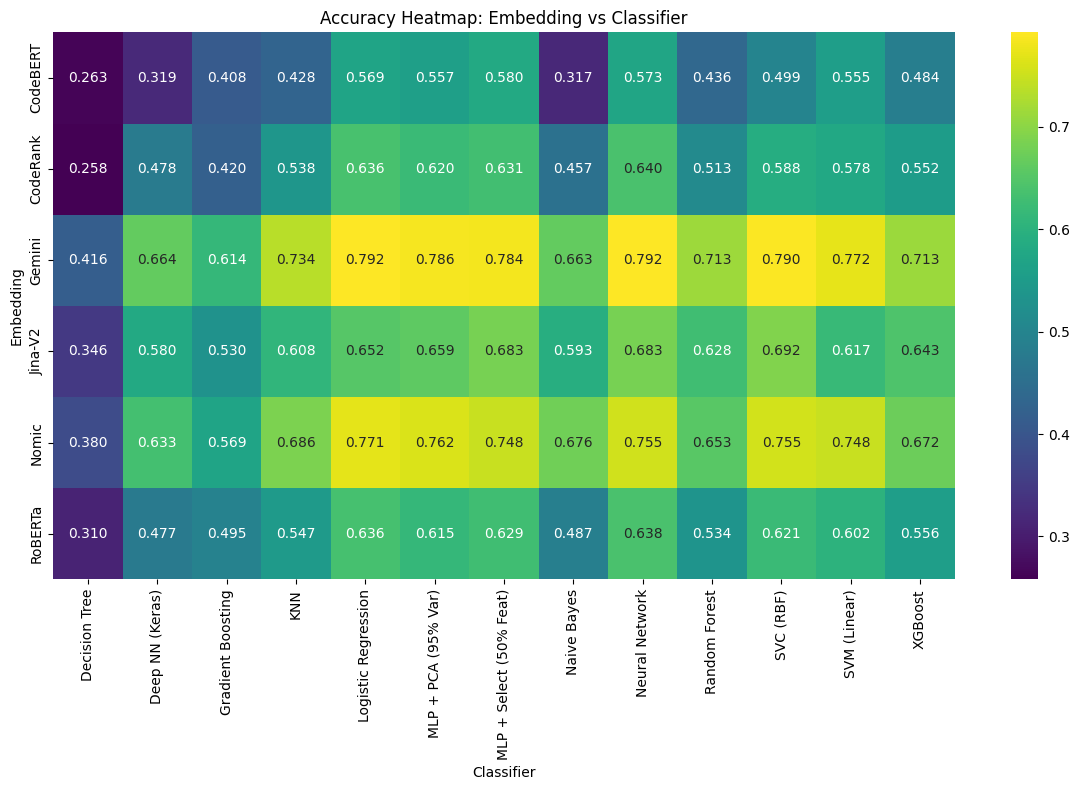

In [21]:
# Re-create DataFrame to include all results from previous sections
if 'results' in locals() and results:
    results_df = pd.DataFrame(results)

if not results_df.empty:
    # Sort by Accuracy
    results_df = results_df.sort_values(by="Mean Accuracy", ascending=False)
    
    print("Top 10 Configurations:")
    print(results_df.head(10).to_markdown(index=False))
    
    # Pivot Table for Heatmap
    try:
        pivot_table = results_df.pivot(index="Embedding", columns="Classifier", values="Mean Accuracy")
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_table, annot=True, cmap="viridis", fmt=".3f")
        plt.title("Accuracy Heatmap: Embedding vs Classifier")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not generate heatmap: {e}")
    
    # Save Results
    results_df.to_csv("/root/AI-Pattern-Mining-Project/experiments-llm/embedding_comparison_results.csv", index=False)
else:
    print("No results to display.")